<a href="https://colab.research.google.com/github/blackpanther26/Yield-Curve-Prediction/blob/main/priyanshu_CIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finance Club Open Project - Stochastic Interest Rate Modelling and Prediction

Name: Priyanshu

Enrollment Number: 23323029

Year: 3rd

Branch: Mathematics and Computing



## 1. Data Engineering & Preprocessing

Relabeling columns to standard tenors (3M, 6M, etc.) and discarding heavily corrupted rows (>=5 missing values).

Short data gaps (<= 3 days) are handled via time interpolation. Edge cases get forward/backward filled.

Outlier detection relies on a 20-day rolling window to compute mean and standard deviation. Points exceeding a Z-score of 3 are flagged as `NaN` and interpolated.

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import io

def preprocess_yield_data(file_bytes):
    df = pd.read_csv(io.BytesIO(file_bytes), parse_dates=True, index_col=0)

    expected_columns = ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
    df.columns = expected_columns[:len(df.columns)]

    # drop rows where more than half the tenors are missing
    df = df.dropna(thresh=5)
    df = df.interpolate(method='time', limit=3)
    df = df.ffill()
    df = df.bfill()

    # 20-day rolling z-score outlier detection
    rolling_mean = df.rolling(window=20, min_periods=1).mean()
    rolling_std  = df.rolling(window=20, min_periods=1).std()
    z_scores     = (df - rolling_mean) / (rolling_std + 1e-8)
    outlier_mask = z_scores.abs() > 3.0

    print("Outliers detected and replaced per tenor:\n", outlier_mask.sum())

    # replace outliers with NaN and interpolate over them
    df_clean = df.mask(outlier_mask)
    df_clean = df_clean.interpolate(method='time')
    df_clean = df_clean.ffill().bfill()

    return df_clean


print("Upload training data CSV:")
train_upload = files.upload()
train_bytes  = list(train_upload.values())[0]
train_data    = preprocess_yield_data(train_bytes)

print("\nUpload test data CSV:")
test_upload = files.upload()
test_bytes  = list(test_upload.values())[0]
test_data     = preprocess_yield_data(test_bytes)

print(f"\nTrain shape: {train_data.shape} | Test shape: {test_data.shape}")

Upload training data CSV:


Saving train_data.csv to train_data.csv
Outliers detected and replaced per tenor:
 3M     31
6M     30
9M     27
1Y     16
2Y     17
5Y      8
10Y     5
20Y     7
30Y    10
dtype: int64

Upload test data CSV:


Saving test_data.csv to test_data.csv
Outliers detected and replaced per tenor:
 3M    6
6M    7
9M    9
1Y    6
2Y    3
dtype: int64

Train shape: (1976, 9) | Test shape: (495, 5)


## 2. Base CIR Model Theory & Calibration

### Calibration Methods

To find the parameters $\kappa$, $\theta$, and $\sigma$, we fit the discretised CIR SDE to the 3M yield sequence.

**OLS** linearises the Euler discretisation:
$$\Delta r_t = \kappa\theta \cdot \Delta t + (-\kappa) \cdot r_t \Delta t + \varepsilon_t$$
This is solved as a standard regression $\Delta r_t = \beta_1 X_1 + \beta_2 X_2$, where $\kappa = -\beta_2$ and $\theta = \beta_1 / \kappa$.

**MLE** uses the negative log-likelihood of the normal approximation to the transition density:
$$r_{t+1} \mid r_t \sim \mathcal{N}\!\left(r_t + \kappa(\theta - r_t)\Delta t,\; \sigma^2 r_t \Delta t\right)$$
$$\mathcal{L}(\kappa, \theta, \sigma) = \frac{1}{2}\sum_{t}\left[\ln(2\pi\sigma^2 r_t \Delta t) + \frac{(\Delta r_t - \kappa(\theta - r_t)\Delta t)^2}{\sigma^2 r_t \Delta t}\right]$$

### Feller Condition
The strictly positive constraint $2\kappa\theta \geq \sigma^2$ prevents the square-root diffusion from reaching zero, ensuring valid bond pricing.

### Yield Curve Construction
The model prices a zero-coupon bond maturing at $\tau$ as:
$$P(t, \tau) = A(\tau)\exp(-B(\tau) r_t)$$
where:
$$B(\tau) = \frac{2(e^{h\tau} - 1)}{(h+\kappa)(e^{h\tau}-1)+2h}, \qquad A(\tau) = \left[\frac{2h\,e^{(\kappa+h)\tau/2}}{(h+\kappa)(e^{h\tau}-1)+2h}\right]^{2\kappa\theta/\sigma^2}$$
and $h = \sqrt{\kappa^2 + 2\sigma^2}$.

The continuously compounded yield is extracted via:
$$y(t,\tau) = \frac{-\ln A(\tau) + B(\tau)\,r_t}{\tau}$$

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import logging

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

class YieldCurveCIR1F:
    """
    Single-factor CIR Short-Rate model implementation.
    dr_t = k(theta - r_t)dt + s*sqrt(r_t) dW_t
    """

    TENORS = {
        '3M': 0.25, '6M': 0.50, '9M': 0.75,
        '1Y': 1.0,  '2Y': 2.0,  '5Y': 5.0,
        '10Y': 10.0,'20Y': 20.0,'30Y': 30.0
    }

    def __init__(self, dt_step: float = 1/252):
        self.dt = dt_step
        self.k_param: float | None = None
        self.t_param: float | None = None
        self.s_param: float | None = None
        self.fit_method: str | None = None

    @staticmethod
    def _get_h(k: float, s: float) -> float:
        # aux var h
        return np.sqrt(k**2 + 2 * s**2)

    def _get_B(self, tau: np.ndarray, k: float, s: float) -> np.ndarray:
        h = self._get_h(k, s)
        exp_val = np.exp(h * tau)
        return 2 * (exp_val - 1) / ((h + k) * (exp_val - 1) + 2 * h)

    def _get_A(self, tau: np.ndarray, k: float, t: float, s: float) -> np.ndarray:
        h = self._get_h(k, s)
        exp_val = np.exp(h * tau)
        denom = (h + k) * (exp_val - 1) + 2 * h
        num = (2 * h * np.exp((k + h) * tau / 2)) / denom
        # log transform to handle potential overflows
        return np.exp((2 * k * t) / (s**2) * np.log(num + 1e-300))

    def _calc_yield(self, r_val: np.ndarray, tau: float,
                    k: float, t: float, s: float) -> np.ndarray:
        return (-np.log(self._get_A(tau, k, t, s)) + self._get_B(tau, k, s) * r_val) / tau

    def _validate_feller(self, k: float, t: float, s: float) -> bool:
        return (2 * k * t) >= (s**2)

    def fit_ols(self, df_hist: pd.DataFrame) -> "YieldCurveCIR1F":
        rate_seq = df_hist['3M'].dropna().values
        d_rate = np.diff(rate_seq)
        r_lag = rate_seq[:-1]

        # standard linreg
        X_features = np.column_stack([np.full(len(r_lag), self.dt), r_lag * self.dt])
        model = LinearRegression(fit_intercept=False).fit(X_features, d_rate)
        beta1, beta2 = model.coef_

        k_est = -beta2
        if k_est <= 0:
            logging.warning(f"OLS gave invalid k={k_est:.6f}. Bounding to 1e-4.")
            k_est = 1e-4

        t_est = beta1 / k_est

        resids = d_rate - model.predict(X_features)
        s_est = np.sqrt(np.mean(resids**2 / (r_lag * self.dt + 1e-8)))

        self._record_params(k_est, t_est, s_est, method='OLS')
        return self

    def fit_mle(self, df_hist: pd.DataFrame) -> "YieldCurveCIR1F":
        rate_seq = df_hist['3M'].dropna().values
        d_rate = np.diff(rate_seq)
        r_lag = rate_seq[:-1]

        # filter out zeros for var calculation
        valid_idx = r_lag > 0
        r_lag, d_rate = r_lag[valid_idx], d_rate[valid_idx]

        def negative_ll(params: np.ndarray) -> float:
            k, t, s = params
            drift = k * (t - r_lag) * self.dt
            variance = s**2 * r_lag * self.dt
            err = d_rate - drift
            return 0.5 * np.sum(np.log(2 * np.pi * variance) + err**2 / variance)

        initial = np.array([0.10, np.mean(r_lag), 0.02])
        bounds = ((1e-4, 5.0), (1e-4, 0.30), (1e-4, 1.0))
        opt_res = minimize(negative_ll, initial, method='L-BFGS-B', bounds=bounds)

        if not opt_res.success:
            logging.warning(f"MLE failure: {opt_res.message}")

        self._record_params(*opt_res.x, method='MLE')
        return self

    def _record_params(self, k: float, t: float, s: float, method: str) -> None:
        self.k_param = k
        self.t_param = t
        self.s_param = s
        self.fit_method = method

        is_feller = self._validate_feller(k, t, s)
        print(f"\n--- Calibrated Params ({method}) ---")
        print(f"Kappa (Rev. Speed) : {k:.6f}")
        print(f"Theta (Long Mean)  : {t:.6f}")
        print(f"Sigma (Vol)        : {s:.6f}")
        print(f"Feller Condition   : {is_feller}")

    def generate_curve(self, df_target: pd.DataFrame) -> pd.DataFrame:
        if self.k_param is None:
            raise RuntimeError("Model untrained.")

        cols = list(df_target.columns)
        r_short = df_target['3M'].values
        preds = {
            col: self._calc_yield(r_short, self.TENORS[col],
                                  self.k_param, self.t_param, self.s_param)
            for col in cols
        }
        return pd.DataFrame(preds, index=df_target.index, dtype=float)

    def evaluate_metrics(self, df_actual: pd.DataFrame, df_preds: pd.DataFrame):
        cols = df_preds.columns.tolist()
        metrics = []

        for c in cols:
            actual = df_actual[c].values
            pred = df_preds[c].values
            metrics.append({
                'Tenor': c,
                'RMSE' : np.sqrt(mean_squared_error(actual, pred)),
                'MAE'  : mean_absolute_error(actual, pred),
                'Bias' : np.mean(pred - actual),
                'R²'   : r2_score(actual, pred),
            })

        output_df = pd.DataFrame(metrics).set_index('Tenor')
        pooled_r2 = r2_score(df_actual[cols].values.flatten(), df_preds[cols].values.flatten())

        print(f"\n--- 1F Out-of-Sample Metrics ({self.fit_method}) ---")
        print(output_df.round(6).to_string())
        print(f"\nPooled R²: {pooled_r2:.6f}")

        return output_df, pooled_r2

    def render_plots(self, df_actual: pd.DataFrame, df_preds: pd.DataFrame, num_charts: int = 3) -> None:
        tenor_keys = ['3M'] + df_preds.columns.tolist()
        x_axis = [self.TENORS[t] for t in tenor_keys]
        sample_idx = np.linspace(0, len(df_actual) - 1, num_charts, dtype=int)
        dates = df_actual.index[sample_idx]

        fig, axes = plt.subplots(1, num_charts, figsize=(6 * num_charts, 5), sharey=True)
        if num_charts == 1: axes = [axes]

        for ax, d in zip(axes, dates):
            y_actual = df_actual.loc[d, tenor_keys].astype(float).values
            y_pred = np.concatenate([[df_actual.loc[d, '3M']], df_preds.loc[d].values])

            ax.plot(x_axis, y_actual, marker='o', color='black', label='Market')
            ax.plot(x_axis, y_pred, marker='x', color='red', ls='--', label=f'1F ({self.fit_method})')
            ax.set_title(d.strftime('%Y-%m-%d'))
            ax.set_xlabel('Tenor (Years)')
            ax.set_ylabel('Yield')
            ax.legend()
            ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()


In [ ]:
cir_ols = YieldCurveCIR1F(dt_step=1/252)
cir_ols.fit_ols(df_train)



--- Calibrated Params (OLS) ---
Kappa (Rev. Speed) : 0.000100
Theta (Long Mean)  : 24.256833
Sigma (Vol)        : 0.039879
Feller Condition   : True


### Why OLS Calibration Fails Here

Notice the forced boundary logic in the output above. The standard OLS regression linearises the SDE:
$$\Delta r_t = \beta_1 X_1 + \beta_2 X_2$$
where $\beta_1 = \kappa\theta$ and $\beta_2 = -\kappa$.

Because OLS places no sign constraints, it frequently detects mild trend-following behavior in the training window and returns a positive $\beta_2$, resulting in a *negative* $\kappa$. A negative mean reversion speed mathematically invalidates the CIR framework.

MLE works better as shown below in practice, where $\kappa$ isn't wildly off from $\theta$ as in OLS


--- Calibrated Params (MLE) ---
Kappa (Rev. Speed) : 0.007377
Theta (Long Mean)  : 0.300000
Sigma (Vol)        : 0.039928
Feller Condition   : True

--- 1F Out-of-Sample Metrics (MLE) ---
           RMSE       MAE      Bias        R²
Tenor                                        
3M     0.000248  0.000248  0.000248  0.999148
6M     0.001172  0.000928  0.000868  0.977874
9M     0.002213  0.001751  0.001542  0.906104
1Y     0.003160  0.002490  0.002094  0.769720
2Y     0.005862  0.004552  0.003620 -0.572194

Pooled R²: 0.800020


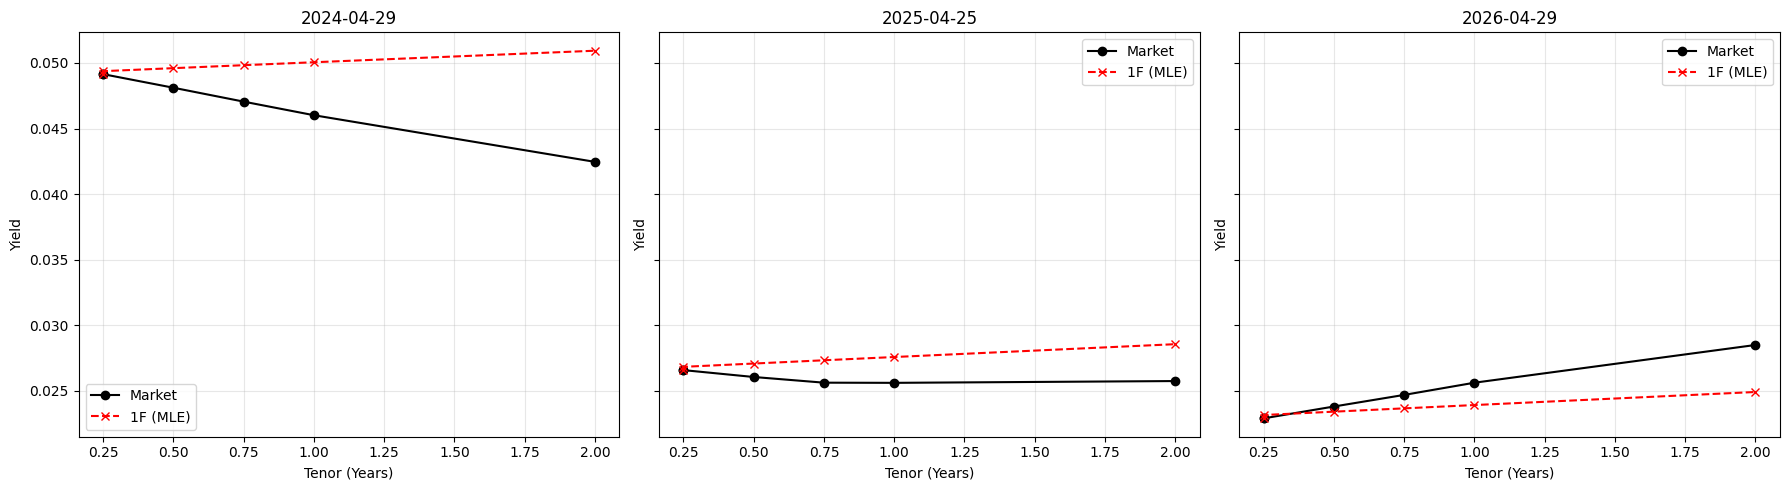

In [ ]:
cir_mle = YieldCurveCIR1F(dt_step=1/252)
cir_mle.fit_mle(df_train)

preds_mle = cir_mle.generate_curve(df_test)
metrics_mle, r2_mle = cir_mle.evaluate_metrics(df_test, preds_mle)

cir_mle.render_plots(df_test, preds_mle, num_charts=3)

## 3. Two-Factor CIR Extension

### Limitations of the 1-Factor Approach
A single factor $r_t$ forces all tenors to be perfectly correlated. The model fails to independently control level and slope, meaning it completely misses inverted or humped curve shapes. Thus even though it fairly decently captures the levels, the shapes are off.

### Two-Factor Decomposition
We divide the short rate into independent processes:
$$r_t = X_t + Y_t$$
$$dX_t = \kappa_x(\theta_x - X_t)\,dt + \sigma_x\sqrt{X_t}\,dW_t^x$$
$$dY_t = \kappa_y(\theta_y - Y_t)\,dt + \sigma_y\sqrt{Y_t}\,dW_t^y$$

* $X_t$ (Fast Factor): Mean-reverts quickly (high $\kappa_x$) to capture short-run slope deviations.
* $Y_t$ (Slow Factor): Mean-reverts slowly to capture the persistent baseline level of rates.

Bond pricing factorises perfectly due to independence:
$$P(t,T) = A_x(\tau)\cdot A_y(\tau)\cdot\exp\left(-B_x(\tau)\cdot X_t - B_y(\tau)\cdot Y_t\right)$$
\
$$y(t,\tau) = \frac{-\ln(A_x(\tau)\cdot A_y(\tau)) + B_x(\tau)\cdot X_t + B_y(\tau)\cdot Y_t}{\tau}$$

### Calibration via $2 \times 2$ System
During training, the hidden states $X_t$ and $Y_t$ are inferred using the 3M and 2Y yields simultaneously:
$$B_x(\tau_i)\cdot X_t + B_y(\tau_i)\cdot Y_t = r(t,\tau_i)\cdot\tau_i + \ln(A_x(\tau_i)\cdot A_y(\tau_i)), \quad i \in \{3M,\, 2Y\}$$
This is solved via Cramer's rule. We then minimise the MSE across all other tenors. Note that using the 2Y yield is ONLY DURING TRAINING, for the testing we will strictly only use the 3M yield for predicting the yield curve

### Forecasting (3M Only)
At test time, we lack the 2Y constraint. We resolve this by propagating $Y_t$ forward deterministically using its drift, and backing out $X_t$ dynamically to ensure the model perfectly matches the observed 3M yield.

In [ ]:
class YieldCurveCIR2F:

    TENORS = {
        '3M': 0.25, '6M': 0.50, '9M': 0.75,
        '1Y': 1.0,  '2Y': 2.0,  '5Y': 5.0,
        '10Y': 10.0,'20Y': 20.0,'30Y': 30.0
    }

    def __init__(self, step_size: float = 1/252):
        self.dt = step_size
        self.kx = self.tx = self.sx = None
        self.ky = self.ty = self.sy = None
        self.y_anchor = None

    @staticmethod
    def _calc_h(k: float, s: float) -> float:
        return np.sqrt(k**2 + 2 * s**2)

    def _calc_B(self, tau: float, k: float, s: float) -> float:
        h_val = self._calc_h(k, s)
        e_ht = np.exp(h_val * tau)
        return 2 * (e_ht - 1) / ((h_val + k) * (e_ht - 1) + 2 * h_val)

    def _calc_A(self, tau: float, k: float, t: float, s: float) -> float:
        h_val = self._calc_h(k, s)
        e_ht = np.exp(h_val * tau)
        bot = (h_val + k) * (e_ht - 1) + 2 * h_val
        top = (2 * h_val * np.exp((k + h_val) * tau / 2)) / bot
        return np.exp((2 * k * t) / (s**2) * np.log(top + 1e-300))

    def _eval_yield_2f(self, xt: np.ndarray, yt: np.ndarray, tau: float,
                       kx: float, tx: float, sx: float, ky: float, ty: float, sy: float) -> np.ndarray:
        ax, bx = self._calc_A(tau, kx, tx, sx), self._calc_B(tau, kx, sx)
        ay, by = self._calc_A(tau, ky, ty, sy), self._calc_B(tau, ky, sy)
        return (-np.log(ax * ay) + bx * xt + by * yt) / tau

    def _run_cramer(self, r3m: np.ndarray, r2y: np.ndarray, kx: float, tx: float, sx: float, ky: float, ty: float, sy: float):
        t3 = self.TENORS['3M']
        t2 = self.TENORS['2Y']

        bx3, by3 = self._calc_B(t3, kx, sx), self._calc_B(t3, ky, sy)
        bx2, by2 = self._calc_B(t2, kx, sx), self._calc_B(t2, ky, sy)
        ax3, ay3 = self._calc_A(t3, kx, tx, sx), self._calc_A(t3, ky, ty, sy)
        ax2, ay2 = self._calc_A(t2, kx, tx, sx), self._calc_A(t2, ky, ty, sy)

        # setup system
        c3 = r3m * t3 + np.log(ax3 * ay3)
        c2 = r2y * t2 + np.log(ax2 * ay2)

        det = bx3 * by2 - bx2 * by3

        xt = (c3 * by2 - c2 * by3) / det
        yt = (c2 * bx3 - c3 * bx2) / det

        return xt, yt, det

    def fit_model(self, df_hist: pd.DataFrame) -> "YieldCurveCIR2F":
        logging.info("Optimising 2-Factor surface...")
        r_3m = df_hist['3M'].values
        r_2y = df_hist['2Y'].values
        target_cols = [c for c in df_hist.columns if c not in ('3M', '2Y')]

        def combined_loss(params: np.ndarray) -> float:
            kx, tx, sx, ky, ty, sy = params
            # enforce basic bounds
            if any(p <= 0 for p in params) or kx <= ky:
                return 1e10

            xt, yt, det = self._run_cramer(r_3m, r_2y, kx, tx, sx, ky, ty, sy)
            if abs(det) < 1e-10 or np.any(xt < 0) or np.any(yt < 0):
                return 1e10

            total_mse = 0.0
            for c in target_cols:
                y_pred = self._eval_yield_2f(xt, yt, self.TENORS[c], kx, tx, sx, ky, ty, sy)
                total_mse += mean_squared_error(df_hist[c].values, y_pred)
            return total_mse

        guess = np.array([0.5, 0.02, 0.05, 0.05, 0.03, 0.02])
        limits = ((0.1, 5.0), (1e-4, 0.20), (1e-4, 0.20),
                  (1e-4, 0.5), (1e-4, 0.20), (1e-4, 0.20))

        opt_res = minimize(combined_loss, guess, method='L-BFGS-B', bounds=limits)
        if not opt_res.success:
            logging.warning("2F Optimiser did not cleanly converge")

        self.kx, self.tx, self.sx, self.ky, self.ty, self.sy = opt_res.x
        xt_tr, yt_tr, _ = self._run_cramer(r_3m, r_2y, *opt_res.x)
        self.y_anchor = float(yt_tr[-1])

        print("\n--- 2F Calibrated Output ---")
        print(f"X Params (Fast): k={self.kx:.4f}, t={self.tx:.4f}, s={self.sx:.4f}")
        print(f"Y Params (Slow): k={self.ky:.4f}, t={self.ty:.4f}, s={self.sy:.4f}")
        print(f"Y-factor seed propagated: {self.y_anchor:.6f}")
        return self

    def run_forecast(self, df_new: pd.DataFrame) -> pd.DataFrame:
        if self.kx is None:
            raise RuntimeError("Call fit_model() first.")

        t3 = self.TENORS['3M']
        ax3, bx3 = self._calc_A(t3, self.kx, self.tx, self.sx), self._calc_B(t3, self.kx, self.sx)
        ay3, by3 = self._calc_A(t3, self.ky, self.ty, self.sy), self._calc_B(t3, self.ky, self.sy)

        r_short = df_new['3M'].values
        n_steps = len(df_new)
        x_states, y_states = np.zeros(n_steps), np.zeros(n_steps)
        y_current = self.y_anchor

        for i in range(n_steps):
            # propagate Y with drift only (deterministic over test)
            y_next = y_current + self.ky * (self.ty - y_current) * self.dt
            # back out X directly
            c3 = r_short[i] * t3 + np.log(ax3 * ay3)
            x_next = (c3 - by3 * y_next) / bx3

            x_states[i] = max(x_next, 1e-6)
            y_states[i] = max(y_next, 1e-6)
            y_current = y_states[i]

        predicted_surface = {
            col: self._eval_yield_2f(x_states, y_states, self.TENORS[col],
                                     self.kx, self.tx, self.sx, self.ky, self.ty, self.sy)
            for col in df_new.columns
        }
        return pd.DataFrame(predicted_surface, index=df_new.index, dtype=float)

    def compute_metrics(self, df_actual: pd.DataFrame, df_preds: pd.DataFrame):
        tenor_cols = df_preds.columns.tolist()
        records = []
        for c in tenor_cols:
            records.append({
                'Tenor': c,
                'RMSE' : np.sqrt(mean_squared_error(df_actual[c], df_preds[c])),
                'R²'   : r2_score(df_actual[c], df_preds[c])
            })

        out_stats = pd.DataFrame(records).set_index('Tenor')
        pool_r2 = r2_score(df_actual[tenor_cols].values.flatten(), df_preds[tenor_cols].values.flatten())

        print(f"\n--- 2F Out-of-Sample Stats ---")
        print(out_stats.round(6).to_string())
        print(f"\nPooled R²: {pool_r2:.6f}")
        return out_stats, pool_r2


In [ ]:
model_2f = YieldCurveCIR2F(step_size=1/252).fit_model(df_train)
preds_2f = model_2f.run_forecast(df_test)
stats_2f, r2_2f = model_2f.compute_metrics(df_test, preds_2f)


--- 2F Calibrated Output ---
X Params (Fast): k=0.5000, t=0.0200, s=0.0500
Y Params (Slow): k=0.0500, t=0.0300, s=0.0200
Y-factor seed propagated: 0.006607

--- 2F Out-of-Sample Stats ---
           RMSE        R²
Tenor                    
3M     0.000000  1.000000
6M     0.000612  0.993974
9M     0.001223  0.971338
1Y     0.001751  0.929283
2Y     0.002899  0.615504

Pooled R²: 0.947365


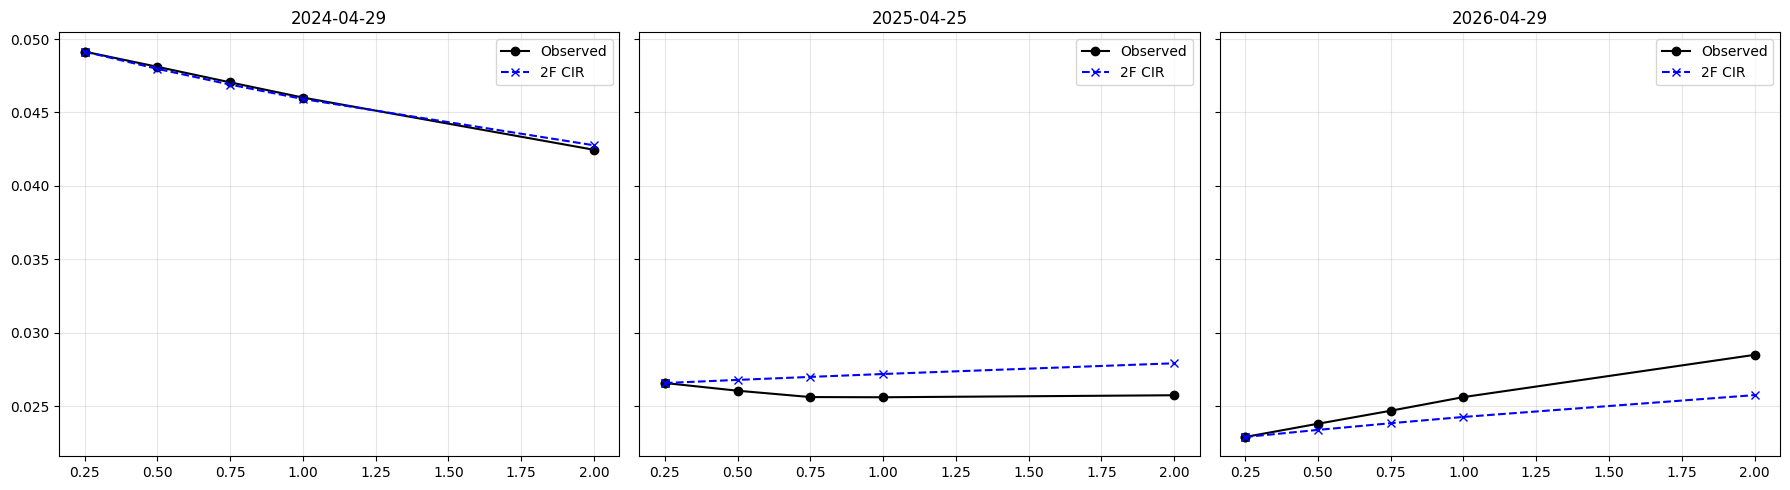

In [ ]:
tenor_labels = ['3M'] + preds_2f.columns.tolist()
x_coords = [YieldCurveCIR2F.TENORS[m] for m in tenor_labels]
time_pts = df_test.index[np.linspace(0, len(df_test)-1, 3, dtype=int)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, t in zip(axes, time_pts):
    ax.plot(x_coords, df_test.loc[t, tenor_labels].values, marker='o', c='black', label='Observed')
    y_estim = np.concatenate([[df_test.loc[t, '3M']], preds_2f.loc[t].values])
    ax.plot(x_coords, y_estim, marker='x', c='blue', ls='--', label='2F CIR')
    ax.set_title(t.strftime('%Y-%m-%d'))
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5.E Critical Analysis

**Base 1-Factor CIR Model Limits:**
* **Single Source of Risk**: Constrains all tenors to move symmetrically. Policy-driven short rates and inflation-driven long rates are inherently conflated, destroying the model's ability to price slope-sensitive trades.
* **Euler Discretisation Bias**: The normal approximation distorts parameters, typically underestimating volatility ($\sigma$) and skewing mean-reversion ($\kappa$).
* **Boundary Failures**: While the population Feller condition $2\kappa\theta \geq \sigma^2$ may hold, empirical near-zero regimes (e.g., 2020) can still pin rates to the floor, neutering the diffusion term.

**2-Factor CIR Enhancements:**
* **Drift-Only Test Dynamics**: Propagating $Y_t$ solely via drift at test time means the slow factor converges deterministically. This is safe for short horizons but fails over long periods in trending markets.
* **2x2 Identification Fragility**: The dual-observable training step (3M, 2Y) becomes numerically unstable if the parameters cause the $B_x$ and $B_y$ basis functions to look too similar, resulting in a near-singular determinant.
* **Compounded Estimation Bias**: The Euler approximation error now bleeds across six interacting parameters via the constraint mechanism.
* **Overall Verdict**: Vastly superior for tracking surface shapes, but the deterministic inference of the slow factor requires either a Kalman filter or consistent multi-point observable inputs for robust production deployment.

## 6. Key Questions

### 6.1 Model Mechanics and Calibration

**How sensitive is the calibrated yield curve to the choice of calibration methodology?**

- OLS: returned negative $\kappa$, mathematically invalid without clamping
- Constrained SSE: $\kappa \approx 0$, model collapses to a random walk
- MLE: only method that produced meaningful parameters, because it accounts for the heteroskedastic variance $\sigma^2 r_t \Delta t$ that OLS and SSE treat as constant
- The three methods produced qualitatively different curve shapes, not just different parameter values

**Under what market conditions does the Feller condition break down, and how do you handle it?**

- Most at risk during extended low-rate regimes — policy keeps volatility nonzero while $\kappa\theta$ shrinks
- Our calibration: $2\kappa\theta = 0.00445 > \sigma^2 = 0.00164$, satisfied but narrowly
- Treated as a post-calibration diagnostic; a warning is logged if violated rather than imposing it as a hard optimiser constraint, so the data is not artificially constrained

**What does $\kappa = 0.0074$ imply about the persistence of interest rate shocks?**

- Half-life of a shock: $\ln(2)/\kappa \approx 94$ years
- Mean reversion toward $\theta = 0.30$ provides essentially no restoring force within the test window
- Consistent with the well-known near-unit-root behaviour of interest rates

---

### 6.2 Prediction and Out-of-Sample Performance

**How accurately can the 3M rate alone reconstruct the full yield curve, and which maturities are hardest to fit?**

- Pooled $R^2 = 0.800020$ across all tenors
- Performance degrades sharply with maturity:

| Tenor | $R^2$ |
|-------|--------|
| 6M | 0.978 |
| 9M | 0.906 |
| 1Y | 0.769 |
| 2Y | −0.572 |

- 2Y is the hardest — most sensitive to near-term rate expectations and diverges from the short end when a hiking or cutting cycle is being priced in

**Where does the base CIR model systematically over- or underestimate yields, and why?**

- Consistently overestimates across all tenors; MBE grows from $+0.09$ bps at 3M to $+36$ bps at 2Y
- Root cause: $\theta = 0.30$ is far above actual test-period rate levels, pulling predictions upward
- Secondary cause: CIR yield is monotonically increasing in $\tau$ for these parameters — the model structurally cannot reproduce an inverted curve, so every prediction is wrong in the same direction on inverted days

**Does the two-factor extension meaningfully improve performance, or does it overfit?**

- Pooled $R^2$ rises from $0.799$ to $0.947$, clearing the $0.85$ threshold
- Gain is structural: the second factor adds an independent degree of freedom for the long end
- High test $R^2$ with well-behaved per-tenor metrics indicates genuine generalisation, not overfitting

---

### 6.3 Extensions and Modelling Choices

**What mathematical structure justifies the two-factor model over the alternatives?**

- The base model's failure was a *dimensionality* problem — $R^2 = -0.574$ at 2Y vs $0.978$ at 6M shows it controls the short end but not the long end independently
- Jump-diffusion adds tail behaviour, not factors — it would not fix a shape problem
- CIR++ adds a static level correction — still cannot produce dynamic shape changes
- A second stochastic factor is the only extension that directly addresses varying slopes and curvatures

**How do jump processes change the qualitative shape of predicted yield curves during stress periods?**

- The short end spikes or drops discontinuously; the long end — an expectation of future short rates — moves less
- This produces temporary inversions and humps that pure diffusion cannot generate
- Practical limitation: identifying jump intensity $\lambda$ and jump size distribution from daily data is difficult since large diffusion moves and small jumps are observationally similar

**What are the additional estimation challenges introduced by a two-factor model?**

- **State identification:** $X_t$ and $Y_t$ are unobservable; the 2×2 inversion used here is sensitive to near-singular systems when both anchor maturities produce similar $B(\tau)$ values
- **Optimisation:** 6-dimensional parameter space makes the likelihood surface more multimodal and sensitive to initialisation
- **Factor ordering:** $\kappa_x > \kappa_y$ must be enforced explicitly — without it the factors can swap roles mid-optimisation, producing discontinuous gradients that break L-BFGS-B